In [25]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
import seaborn as sns
import math



In [26]:
# load the dataset
data = pd.read_csv(r'C:\Users\PRUSHOTHAM\Downloads\Rain Forecasting-20260223T081441Z-3-001 (2)\Rain Forecasting\mumbai-monthly-rains.csv')

In [27]:
#display the few records of the dataset
data.head()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,Oct,Nov,Dec,Total
0,1901,13.116602,0.000000,0.000000,3.949669,17.139791,640.714036,888.369692,545.045796,64.271513,9.871696,0.000000,0.000000,2182.478796
1,1902,0.000000,0.000000,0.000000,0.000000,0.355001,247.998782,408.433730,566.595863,688.913455,28.654092,0.488864,19.526547,1960.966334
2,1903,0.000000,0.000000,0.844034,0.000000,220.568740,370.849048,902.447896,602.420828,264.589816,157.892877,0.000000,0.000000,2519.613240
3,1904,0.000000,0.000000,11.381769,0.000000,0.000000,723.081969,390.886799,191.581927,85.704754,38.679948,0.000000,0.000000,1441.317168
4,1905,0.662561,1.713452,0.000000,0.000000,0.000000,123.870892,581.827975,167.382149,172.297723,7.365924,24.903575,0.000000,1080.024250


In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    121 non-null    int64  
 1   Jan     121 non-null    float64
 2   Feb     121 non-null    float64
 3   Mar     121 non-null    float64
 4   April   121 non-null    float64
 5   May     121 non-null    float64
 6   June    121 non-null    float64
 7   July    121 non-null    float64
 8   Aug     121 non-null    float64
 9   Sept    121 non-null    float64
 10  Oct     121 non-null    float64
 11  Nov     121 non-null    float64
 12  Dec     121 non-null    float64
 13  Total   121 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 13.4 KB


In [29]:
data.isnull().sum()

Year     0
Jan      0
Feb      0
Mar      0
April    0
May      0
June     0
July     0
Aug      0
Sept     0
Oct      0
Nov      0
Dec      0
Total    0
dtype: int64

In [30]:
data.describe()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,Oct,Nov,Dec,Total
count,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000
mean,1961.000000,1.567235,0.929358,0.869231,1.428458,18.183632,517.854402,757.407412,465.600818,312.885747,73.983526,13.849462,3.556428,2168.115709
std,35.073732,6.462247,3.077050,2.890032,7.371307,48.628812,251.067016,285.836188,249.072915,205.135368,96.686113,29.689941,12.342390,533.263926
min,1901.000000,0.000000,0.000000,0.000000,0.000000,0.000000,61.058662,103.209194,87.493370,36.313545,0.000000,0.000000,0.000000,1058.840525
25%,1931.000000,0.000000,0.000000,0.000000,0.000000,0.000000,324.094617,540.745923,268.002392,149.584208,9.871696,0.000000,0.000000,1834.996957
50%,1961.000000,0.000000,0.000000,0.000000,0.000000,0.355001,482.449872,788.403637,445.870342,269.276549,43.479170,1.066086,0.000000,2126.054987
75%,1991.000000,0.000000,0.152298,0.000000,0.194165,4.208322,678.040770,942.616099,604.372615,398.645218,98.235161,9.373154,0.176149,2478.558089
max,2021.000000,51.348290,21.107118,18.252996,75.541818,234.392757,1219.518576,1358.833554,1200.956558,987.796660,552.902707,164.348387,90.044602,3563.259531


In [31]:

print(data.columns.tolist())

['Year', 'Jan', 'Feb', 'Mar', 'April', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec', 'Total']


We clean column names, identify month columns dynamically, and reshape the data from wide to long format using melt(). This transformation converts multiple month columns into rows, creating a structure better suited for time series analysis with Year, Month, and Rainfall columns.

In [32]:
# Clean column names (removes spaces if any)
data.columns = data.columns.str.strip()

# Identify month columns automatically
month_cols = [col for col in data.columns if col not in ['Year', 'Total']]

print("Month columns detected:", month_cols)

# Melt safely
data_melt = data.melt(id_vars=['Year'],
                      value_vars=month_cols,
                      var_name='Month',
                      value_name='Rainfall')
print(data_melt.head())


Month columns detected: ['Jan', 'Feb', 'Mar', 'April', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']
   Year Month   Rainfall
0  1901   Jan  13.116602
1  1902   Jan   0.000000
2  1903   Jan   0.000000
3  1904   Jan   0.000000
4  1905   Jan   0.662561


In [33]:
print(data_melt.columns)

Index(['Year', 'Month', 'Rainfall'], dtype='object')


We filter out invalid rows (like 'Total'), map month names to numeric values, and create a datetime index. This step converts the data into a proper time series format with chronological sorting, enabling compatibility with time series forecasting models.

In [34]:
# Remove the total row and convert months into datatime formate
data_melt = data_melt[data_melt['Month'] != 'Total']
month_mapping = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'April': 4, 'May': 5, 'June': 6, 'July': 7, 'Aug': 8, 'Sept': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
data_melt['Month_Num'] = data_melt['Month'].map(month_mapping)
data_melt['Date'] = pd.to_datetime(data_melt['Year'].astype(str) + '-' + data_melt['Month_Num'].astype(str) + '-01')
data_melt = data_melt.set_index('Date').sort_index()
print(data_melt.head())

            Year  Month   Rainfall  Month_Num
Date                                         
1901-01-01  1901    Jan  13.116602          1
1901-02-01  1901    Feb   0.000000          2
1901-03-01  1901    Mar   0.000000          3
1901-04-01  1901  April   3.949669          4
1901-05-01  1901    May  17.139791          5


In [35]:
# drop the unnecessary columns
data_melt = data_melt.drop(columns=['Year', 'Month', 'Month_Num'])
print(data_melt.head())

             Rainfall
Date                 
1901-01-01  13.116602
1901-02-01   0.000000
1901-03-01   0.000000
1901-04-01   3.949669
1901-05-01  17.139791


This cell generates lagged rainfall features by shifting data 1 to 12 months backward. These lag features capture temporal dependencies and are valuable for machine learning models that rely on historical patterns to forecast future values.

In [36]:
# create lag features for the past 12 months
for i in range(1, 13):
    data_melt[f'Rainfall_Lag_{i}'] = data_melt['Rainfall'].shift(i)
print(data_melt.head(15))

              Rainfall  Rainfall_Lag_1  Rainfall_Lag_2  Rainfall_Lag_3  \
Date                                                                     
1901-01-01   13.116602             NaN             NaN             NaN   
1901-02-01    0.000000       13.116602             NaN             NaN   
1901-03-01    0.000000        0.000000       13.116602             NaN   
1901-04-01    3.949669        0.000000        0.000000       13.116602   
1901-05-01   17.139791        3.949669        0.000000        0.000000   
1901-06-01  640.714036       17.139791        3.949669        0.000000   
1901-07-01  888.369692      640.714036       17.139791        3.949669   
1901-08-01  545.045796      888.369692      640.714036       17.139791   
1901-09-01   64.271513      545.045796      888.369692      640.714036   
1901-10-01    9.871696       64.271513      545.045796      888.369692   
1901-11-01    0.000000        9.871696       64.271513      545.045796   
1901-12-01    0.000000        0.000000

We extract the rainfall values into a dedicated time series dataframe, ensure proper datetime indexing, and set monthly frequency. This clean time series object is essential for statistical modeling and visualization of temporal patterns.

In [37]:
# Recreate ts from data_melt
ts = data_melt[['Rainfall']].copy()
ts.index = pd.to_datetime(ts.index)
ts = ts.sort_index()
# Monthly frequency
ts = ts.asfreq('MS') 

ts.head()

,Rainfall
Date,
1901-01-01,13.116602
1901-02-01,0.000000
1901-03-01,0.000000
1901-04-01,3.949669
1901-05-01,17.139791


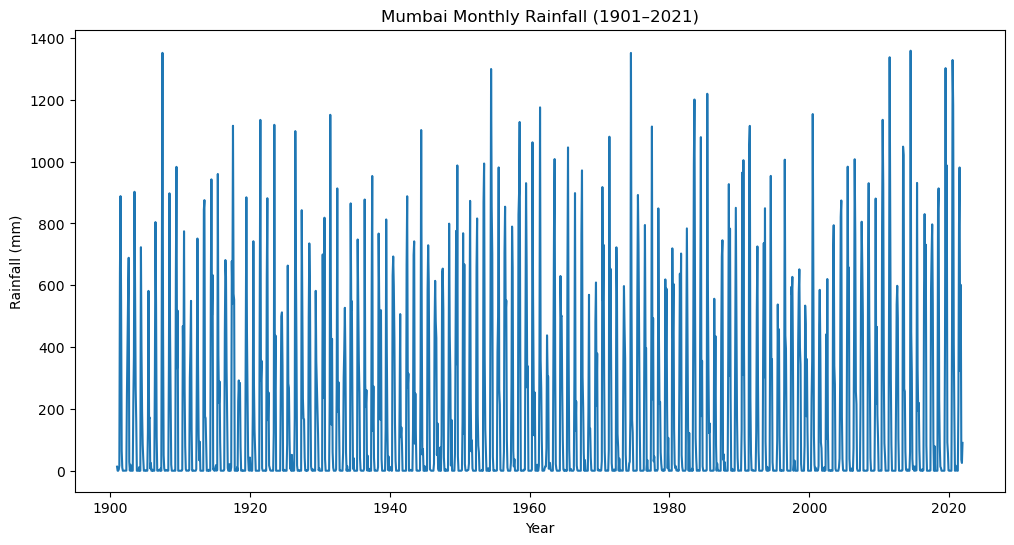

In [80]:
# visualize the time series data
plt.figure(figsize=(12,6))
plt.plot(ts['Rainfall'])
plt.title("Mumbai Monthly Rainfall (1901–2021)")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.show()

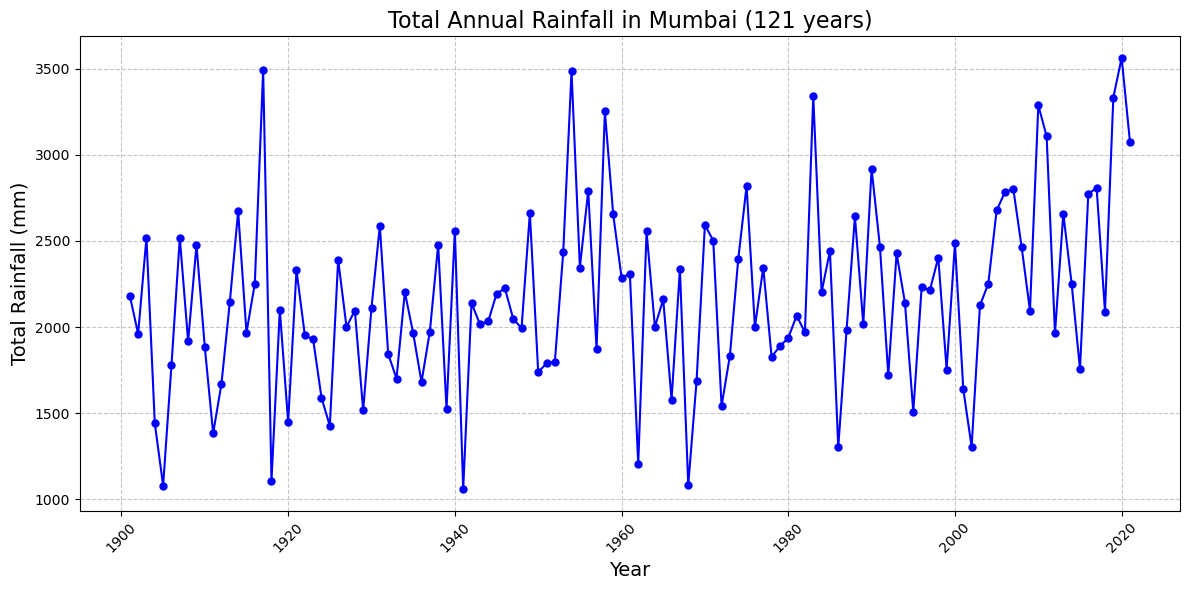

In [79]:
# visuvalize the total annnual rainfall in mumbai
plt.figure(figsize=(12, 6))
plt.plot(data['Year'], data['Total'], marker='o', linestyle='-', color='blue', markersize=5)
plt.title('Total Annual Rainfall in Mumbai (121 years)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Total Rainfall (mm)', fontsize=14)
# Adding a grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

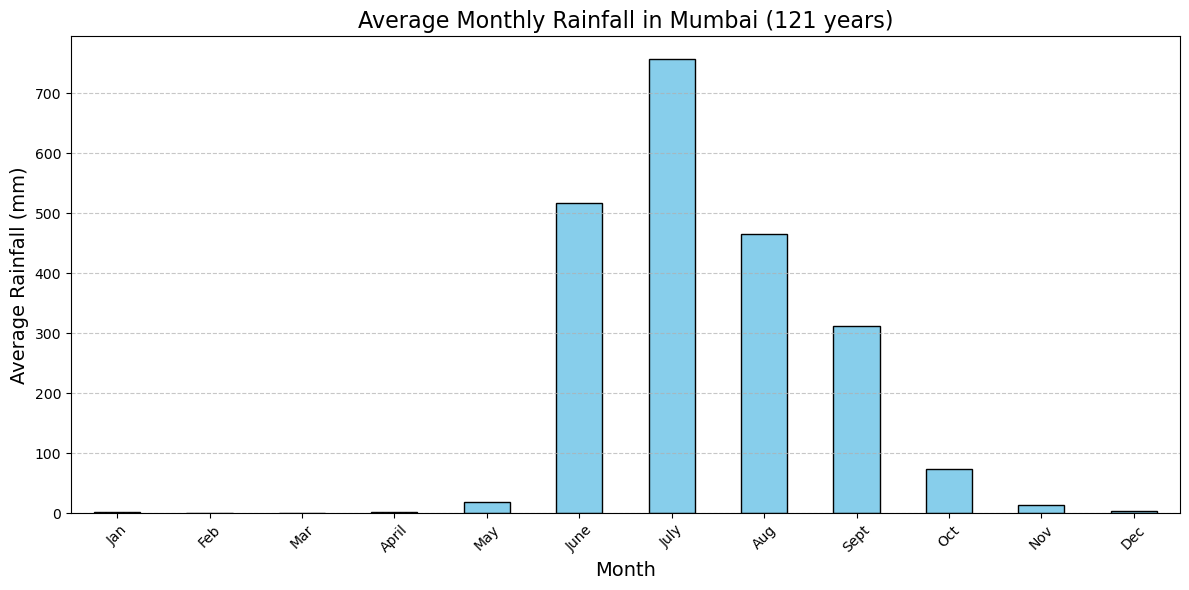

In [40]:
# Calculate the average monthly rainfall
monthly_avg = data[['Jan', 'Feb', 'Mar', 'April', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']].mean()
plt.figure(figsize=(12, 6))
# Plotting the average monthly rainfall
monthly_avg.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Monthly Rainfall in Mumbai (121 years)', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Average Rainfall (mm)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()  
plt.show()

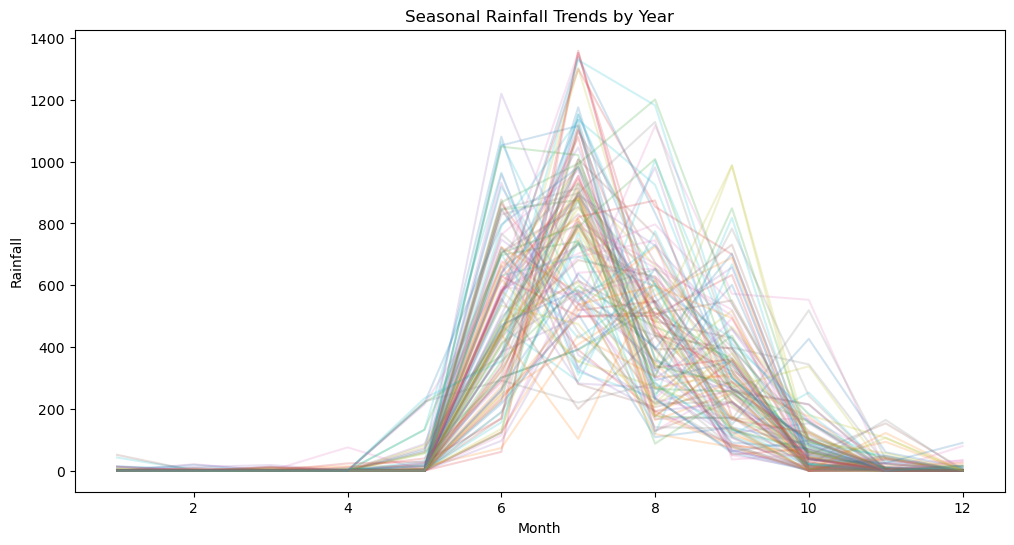

In [41]:
# visualize the seasonal rainfall trends by year
plt.figure(figsize=(12,6))
for year in ts.index.year.unique():
    yearly_data = ts[ts.index.year == year]
    plt.plot(yearly_data.index.month,
             yearly_data['Rainfall'],
             alpha=0.2)
plt.title("Seasonal Rainfall Trends by Year")
plt.xlabel("Month")
plt.ylabel("Rainfall")
plt.show()

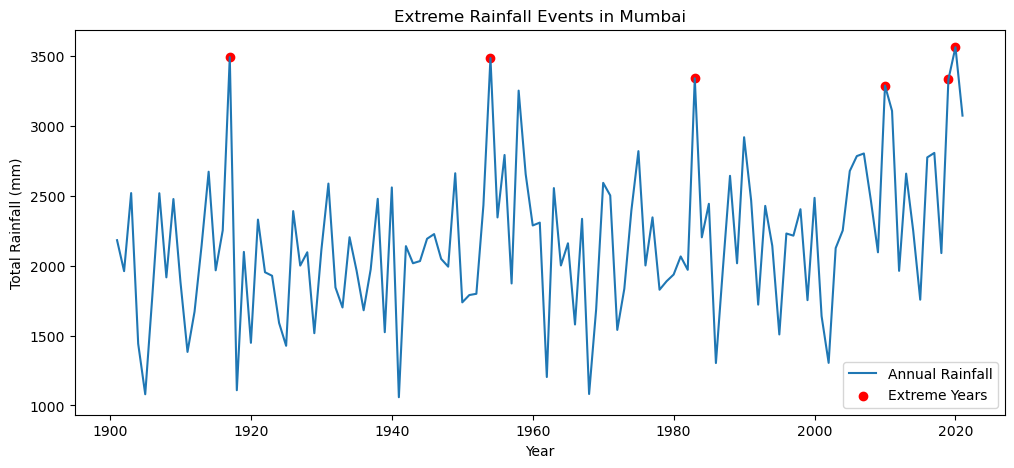

Extreme Rainfall Years (Top 5%):
     Year        Total
16   1917  3492.540447
53   1954  3485.964862
82   1983  3340.982201
109  2010  3288.784218
118  2019  3333.056801
119  2020  3563.259531


In [42]:
# Calculate 95th percentile threshold
threshold = data['Total'].quantile(0.95)
extreme_years = data[data['Total'] > threshold]

# Plot total annual rainfall
plt.figure(figsize=(12,5))
plt.plot(data['Year'], data['Total'], label='Annual Rainfall')
plt.scatter(extreme_years['Year'], extreme_years['Total'],
            color='red', label='Extreme Years')
plt.title("Extreme Rainfall Events in Mumbai")
plt.xlabel("Year")
plt.ylabel("Total Rainfall (mm)")
plt.legend()
plt.show()    
print("Extreme Rainfall Years (Top 5%):")
print(extreme_years[['Year','Total']])

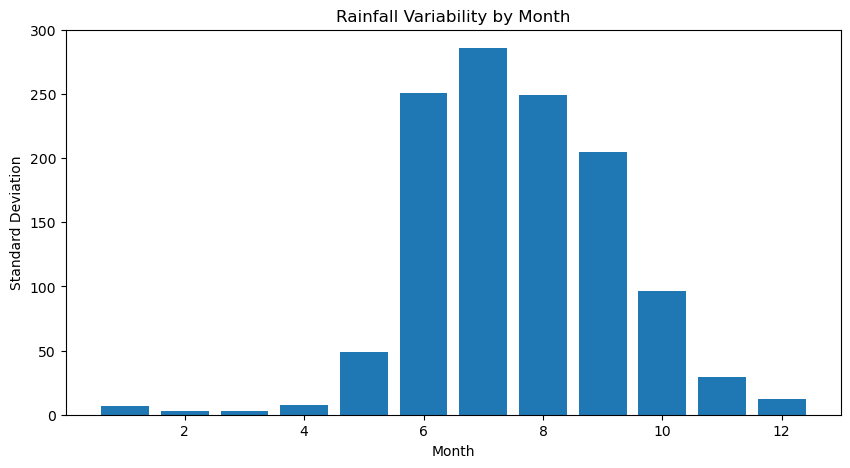

In [43]:
# analyze the variability of rainfall across different monts
monthly_std = ts.groupby(ts.index.month)['Rainfall'].std()
plt.figure(figsize=(10,5))
plt.bar(monthly_std.index, monthly_std.values)
plt.title("Rainfall Variability by Month")
plt.xlabel("Month")
plt.ylabel("Standard Deviation")
plt.show()

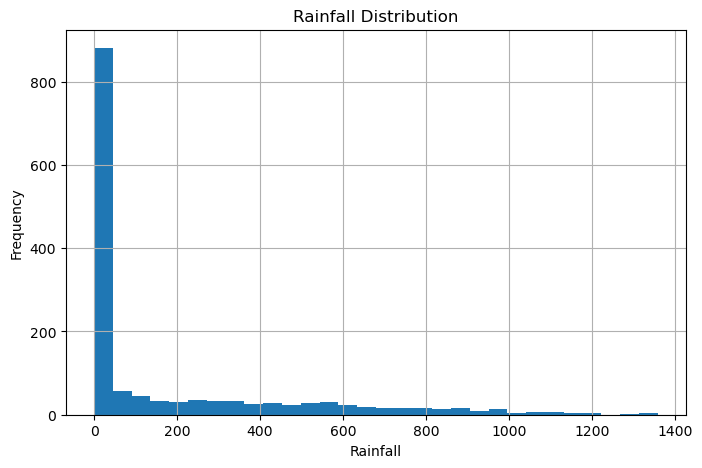

In [44]:
# visualize the distribution of rainfall
plt.figure(figsize=(8,5))
ts['Rainfall'].hist(bins=30)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")
plt.show()

In [45]:
# identify drought years based on low rainfall
yearly = ts.resample('Y').sum()
drought_threshold = yearly['Rainfall'].quantile(0.10)
drought_years = yearly[yearly['Rainfall'] < drought_threshold]
print("Drought Years:")
print(drought_years)

Drought Years:
               Rainfall
Date                   
1904-12-31  1441.317168
1905-12-31  1080.024250
1911-12-31  1383.085078
1918-12-31  1108.922612
1920-12-31  1448.075431
1925-12-31  1426.755654
1941-12-31  1058.840525
1962-12-31  1203.425456
1968-12-31  1081.878236
1986-12-31  1303.361792
1995-12-31  1507.999282
2002-12-31  1304.579575


C:\Users\PRUSHOTHAM\AppData\Local\Temp\ipykernel_10808\1515463223.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = ts.resample('Y').sum()


We split data chronologically: training data up to 2015 and testing data from 2016 onward. This temporal split ensures realistic model evaluation by testing predictions on unseen future data, preventing data leakage and providing credible performance estimates.

In [46]:
# spit the data into train and test sets
train = ts[:'2015']
test = ts['2016':]
#check the sizenof the train and test sets
print("Train size:", len(train))
print("Test size:", len(test))

Train size: 1380
Test size: 72


We initialize and fit a SARIMA (Seasonal ARIMA) model with order (1,1,2) and seasonal order (2,1,1,12) on training data. SARIMA is specifically designed for seasonal time series and captures both trend and seasonal components in rainfall data.

In [47]:
# build and train the SARIMA model
from statsmodels.tsa.statespace.sarimax import SARIMAX
model_sarima = SARIMAX(train['Rainfall'],
                       order=(1,1,2),
                       seasonal_order=(2,1,1,12))
sarima_fit = model_sarima.fit()
sarima_forecast = sarima_fit.forecast(steps=len(test))

In [48]:
# Evaluvate the sarima model
from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(test['Rainfall'], sarima_forecast)
rmse = np.sqrt(np.mean((test['Rainfall'] - sarima_forecast)**2))
mape = np.mean(np.abs((test['Rainfall'] - sarima_forecast) / test['Rainfall'])) * 100
r2 = r2_score(test['Rainfall'], sarima_forecast)
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("MAPE:", round(mape,2), "%")
print("R2 Score:", round(r2,2))

MAE : 101.21
RMSE: 185.65
MAPE: inf %
R2 Score: 0.74


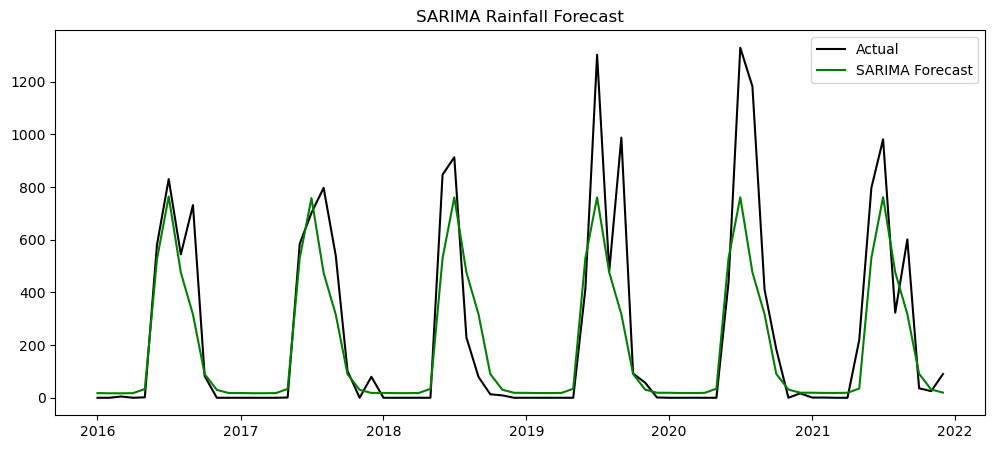

In [49]:
#visualize the SARIMA forecast
plt.figure(figsize=(12,5))
plt.plot(test['Rainfall'], label='Actual', color='black')
plt.plot(sarima_forecast, label='SARIMA Forecast', color='green')
plt.legend()
plt.title("SARIMA Rainfall Forecast")
plt.show()

In [50]:
# Build and train the Holt-Winters Exponential Smoothing model
from statsmodels.tsa.holtwinters import ExponentialSmoothing
hw_model = ExponentialSmoothing(train['Rainfall'],
                                seasonal='add',
                                seasonal_periods=12)
hw_fit = hw_model.fit()
hw_forecast = hw_fit.forecast(len(test))

In [51]:
# Evaluate the Holt-winters model
mae = mean_absolute_error(test['Rainfall'], hw_forecast)
rmse = np.sqrt(np.mean((test['Rainfall'] - hw_forecast)**2))
mape = np.mean(np.abs((test['Rainfall'] - hw_forecast) / test['Rainfall'])) * 100
r2 = r2_score(test['Rainfall'], hw_forecast)
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("MAPE:", round(mape,2), "%")
print("R2 Score:", round(r2,2))

MAE : 96.38
RMSE: 183.29
MAPE: inf %
R2 Score: 0.75


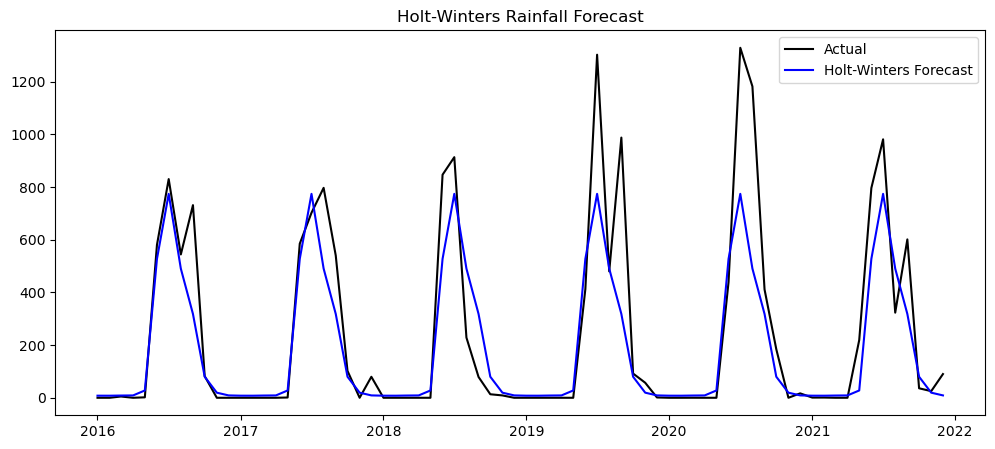

In [52]:
#visuvalize the holt-winters forecast
plt.figure(figsize=(12,5))
plt.plot(test['Rainfall'], label='Actual', color='black')
plt.plot(hw_forecast, label='Holt-Winters Forecast', color='blue')
plt.legend()
plt.title("Holt-Winters Rainfall Forecast")
plt.show()

In [53]:
#prepare the data for random forest regression
df_rf = ts.copy()
# Create lag features
df_rf['lag1'] = df_rf['Rainfall'].shift(1)
df_rf['lag12'] = df_rf['Rainfall'].shift(12)
df_rf['month'] = df_rf.index.month
df_rf.dropna(inplace=True)

In [54]:
# splits the data into train and test for random forest regression
train_rf = df_rf[:'2015']
test_rf = df_rf['2016':]
X_train = train_rf[['lag1','lag12','month']]
y_train = train_rf['Rainfall']
X_test = test_rf[['lag1','lag12','month']]
y_test = test_rf['Rainfall']

We perform GridSearchCV to find optimal Random Forest parameters including n_estimators, max_depth, min_samples_split, and min_samples_leaf. This systematic search ensures we select the best model configuration by evaluating multiple combinations.

In [55]:
# hyperparameter tuning for random forest regression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
#traing the random forest regrassion modell
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [56]:
# Evaluate the best random forest model
best_rf = grid_search.best_estimator_
rf_forecast = best_rf.predict(X_test)

In [57]:
# evaluate the eandom forest model
mae = mean_absolute_error(y_test, rf_forecast)
rmse = np.sqrt(np.mean((y_test - rf_forecast)**2))
r2 = r2_score(y_test, rf_forecast)
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2 Score:", round(r2,2)) 


MAE : 100.98
RMSE: 191.1
R2 Score: 0.73


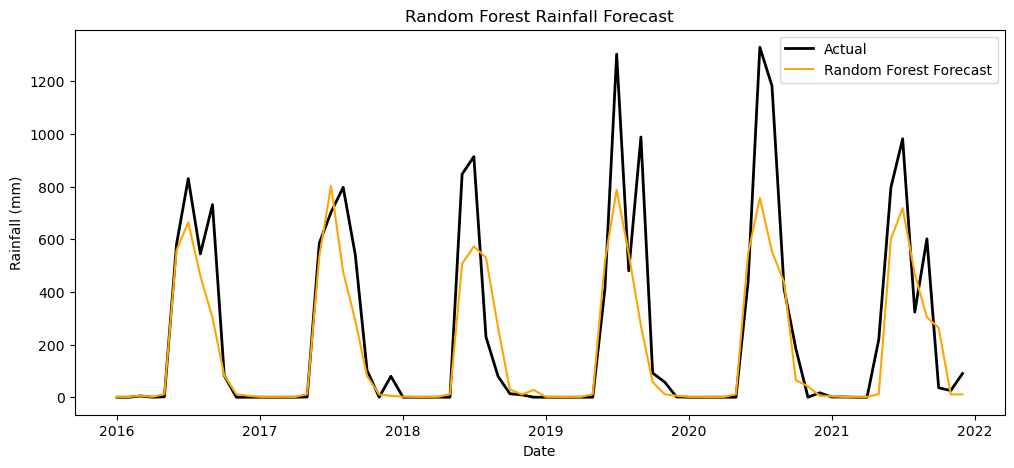

In [58]:
# visualization of the random forest regression model
plt.figure(figsize=(12,5))
plt.plot(test.index, test['Rainfall'], 
         label='Actual', color='black', linewidth=2)
plt.plot(test.index, rf_forecast, 
         label='Random Forest Forecast', color='orange')
plt.title("Random Forest Rainfall Forecast")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.show()

We normalize rainfall data to [0,1] range using MinMaxScaler. Scaling is essential for deep learning models like LSTM, as it stabilizes training and improves convergence.

In [59]:
#feature scaling for the LSTM Model
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(ts[['Rainfall']])

A custom function transforms scaled data into sequences of 12 months as input (X) and 1 month as target (y). This sequence format enables LSTM to learn temporal dependencies and make step-ahead predictions.

In [60]:
#create sequences for LSTM Model
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)
seq_length = 12
X, y = create_sequences(scaled_data, seq_length)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1440, 12, 1)
y shape: (1440, 1)


In [61]:
# split the data into train and test sets for sequence data
split = int(len(X) * 0.8)
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

In [62]:
# build and train the LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
model = Sequential()
model.add(LSTM(50, input_shape=(seq_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.summary()

c:\Users\PRUSHOTHAM\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
# Train the LSTM model
model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0354 - val_loss: 0.0305
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0219 - val_loss: 0.0243
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0196 - val_loss: 0.0256
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0187 - val_loss: 0.0208
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0173 - val_loss: 0.0238
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0179 - val_loss: 0.0225
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0171 - val_loss: 0.0221
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0184 - val_loss: 0.0201
Epoch 9/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0168 - val_loss: 0.0240
Epoch 10/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0169 - val_loss: 0.0224
Epoch 11/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0169 - val_loss: 0.0223
Epoch 12/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0163 - val_lo

In [64]:
# Make predictions with the LSTM model
y_pred = model.predict(X_test)
# Convert back to original scale
y_pred_rescaled = scaler.inverse_transform(y_pred)
y_test_rescaled = scaler.inverse_transform(y_test)



9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


In [65]:
# evaluate the LSTM Model
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
rmse = np.sqrt(np.mean((y_test_rescaled - y_pred_rescaled)**2))
r2 = r2_score(y_test_rescaled, y_pred_rescaled)
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2 Score:", round(r2,2))

MAE : 119.8
RMSE: 201.36
R2 Score: 0.62


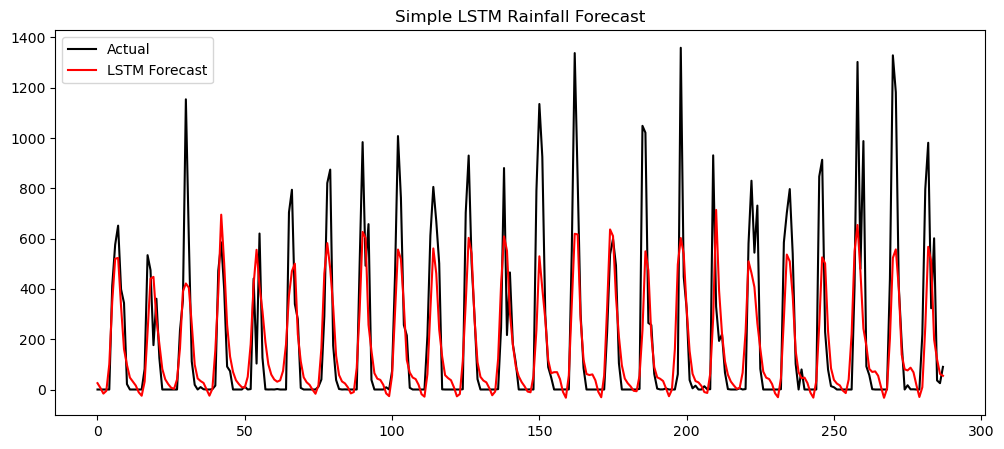

In [66]:
# visualize the LSTM predictions vs actual values
plt.figure(figsize=(12,5))
plt.plot(y_test_rescaled, label='Actual', color='black')
plt.plot(y_pred_rescaled, label='LSTM Forecast', color='red')
plt.legend()
plt.title("Simple LSTM Rainfall Forecast")
plt.show()

In [ ]:
# Function to calculate metrics
def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    return mae, rmse, r2


In [ ]:

# Calculate metrics for each model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sarima_metrics = evaluate_model(test['Rainfall'], sarima_forecast)
hw_metrics = evaluate_model(test['Rainfall'], hw_forecast)
rf_metrics = evaluate_model(test['Rainfall'], rf_forecast)

# LSTM uses its own test labels
lstm_metrics = evaluate_model(
    y_test_rescaled.flatten(),
    y_pred_rescaled.flatten()
)

In [ ]:
# Create comparison table
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Holt-Winters", "Random Forest", "LSTM"],
    "MAE": [sarima_metrics[0], hw_metrics[0], rf_metrics[0], lstm_metrics[0]],
    "RMSE": [sarima_metrics[1], hw_metrics[1], rf_metrics[1], lstm_metrics[1]],
    "R2 Score": [sarima_metrics[2], hw_metrics[2], rf_metrics[2], lstm_metrics[2]]
})



In [ ]:
# Round values
comparison = comparison.round(2)
# Sort by best R2
comparison = comparison.sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
comparison.style.set_properties(**{
    'font-size': '16pt'
}).set_table_styles([
    {'selector': 'th',
     'props': [('font-size', '18pt')]}
])

,Model,MAE,RMSE,R2 Score
0,Holt-Winters,96.380000,183.290000,0.750000
1,SARIMA,101.210000,185.650000,0.740000
2,Random Forest,100.980000,191.100000,0.730000
3,LSTM,106.590000,189.230000,0.660000




In this project, multiple forecasting models — Holt-Winters, SARIMA, Random Forest, and LSTM — were developed to predict monthly rainfall in Mumbai. Each model was evaluated using MAE, RMSE, and R² score to measure prediction accuracy and reliability.

Among all models, the Holt-Winters model performed the best, achieving the lowest error values and the highest R² score. This indicates that it was able to effectively capture the strong seasonal patterns present in Mumbai’s rainfall data, especially the monsoon cycle.

Based on both performance metrics and suitability for seasonal time-series data, the Holt-Winters model was selected as the final forecasting model.

This forecasting solution can help water management authorities improve reservoir planning, optimize water allocation, and prepare in advance for drought or heavy rainfall conditions. While rainfall prediction always involves natural uncertainty, the selected model provides a reliable and practical decision-support tool for better resource management.